# 1D Heat Equation via Finite Volume Method

This notebook imports the solver from `heat_equation_fvm.py` and computes the time evolution of the 1D heat equation, $u_t = \kappa u_{xx}$.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import heat_equation_fvm

In [10]:
# Parameters for the finite volume solver
nx = 200
nt = 4000
t_end = 0.1
kappa = 0.5
length = 1.0
left_bc = 1.0
right_bc = 2.0

# Reload the module to get the latest changes
importlib.reload(heat_equation_fvm)

initial_condition = heat_equation_fvm.linear_initial_condition

x, times, solutions = heat_equation_fvm.solve_heat_equation_fvm(
    nx=nx,
    nt=nt,
    t_end=t_end,
    length=length,
    kappa=kappa,
    left_bc=left_bc,
    right_bc=right_bc,
    initial_condition=initial_condition,
)

print(f'Computed solution on {nx} cells and {nt} time steps.')
print(f'Time step dt = {t_end/nt:.5e}')

Computed solution on 200 cells and 4000 time steps.
Time step dt = 2.50000e-05


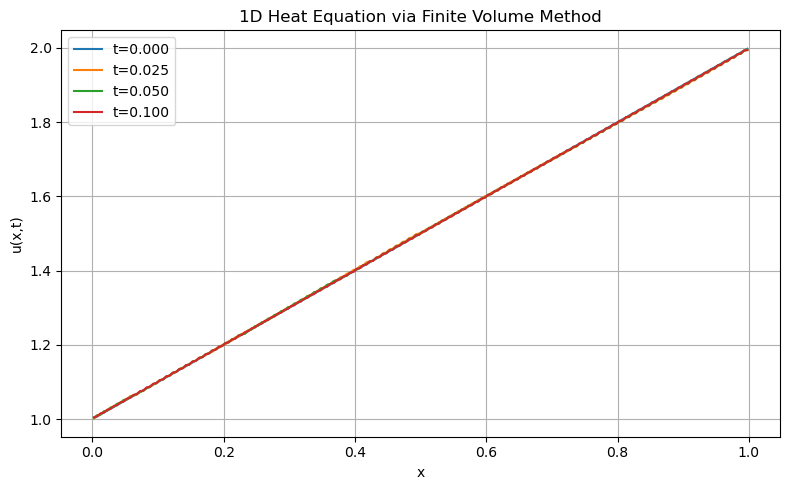

In [11]:
selected_indices = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(8, 5))
for idx in selected_indices:
    plt.plot(x, solutions[idx], label=f't={times[idx]:.3f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('1D Heat Equation via Finite Volume Method')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Compute fractional differences from initial state
initial_state = solutions[0]
fractional_diffs = np.array([(sol - initial_state) / np.where(initial_state != 0, initial_state, 1) for sol in solutions])

# Compute average and max fractional difference for each time step
avg_fractional_diff = np.mean(np.abs(fractional_diffs), axis=1)
max_fractional_diff = np.max(np.abs(fractional_diffs), axis=1)

# Plot average and max fractional differences vs time
plt.figure(figsize=(8, 5))
plt.plot(times, avg_fractional_diff, label='Average |fractional difference|', marker='o')
plt.plot(times, max_fractional_diff, label='Max |fractional difference|', marker='s')
plt.xlabel('Time')
plt.ylabel('Fractional Difference')
plt.title('Fractional Difference from Initial State vs Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()